## Instructions

Your task is to explore the IMDB Movie Dataset, which includes columns like Series_Title, Released_Year, Certificate, Runtime, Genre, IMDB_Rating, Meta_score, Director, Stars, No_of_votes, and Gross.

1. Load and Inspect Data:

    - Use pandas to load the IMDB Movie Dataset.
    - Inspect the data to understand its structure and contents.

2. Data Preprocessing:

    - Handle missing values and convert data types as needed.

3. Rating Trends Over Years:

    - Create a line plot with Matplotlib showing trends in IMDB_Rating over the years.

4. Genre Popularity Analysis:

    - Generate a Seaborn bar plot to compare the number of movies across different genres.

5. Director’s Impact on Ratings:

    - Use a Matplotlib scatter plot to examine the relationship between directors and movie ratings.

6. Star Power Analysis:

    - Employ a Seaborn pairplot to explore relationships involving Stars and their impact on IMDB_Rating and Gross.

7. Box Plot of Genres vs. Ratings:

    - Visualize the distribution of IMDB_Rating across different Genres using a Seaborn box plot.

8. Correlation Heatmap:

    - Create a heatmap using Seaborn to identify correlations between numerical columns like IMDB_Rating, Meta_score, No_of_votes, and Gross.

### Answer

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.ticker as ticker

# ========= BASIC WORKFLOW ===========

df = pd.read_csv('data/imdb_top_1000.csv')

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [97]:
df.shape

(1000, 16)

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


In [99]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [100]:
# ========== DATASET PREPROCESSING ============

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [101]:
# Turn all non-null values from 'Certificate' to mode

print(f'Number of nulls in Certificate before impute: {df['Certificate'].isnull().sum()}')

# Create imputer
imputer = SimpleImputer(strategy='most_frequent')
# Impute the mode to NaN values in Certificate (since the data is categorical)
df['Certificate'] = imputer.fit_transform(df[['Certificate']]).ravel()

print(f'Number of nulls in Certificate after impute: {df['Certificate'].isnull().sum()}')

Number of nulls in Certificate before impute: 101
Number of nulls in Certificate after impute: 0


In [102]:
# Check the difference between the mean and the median Metascore 
print(f'Metascore median: {df['Meta_score'].median()}')
print(f'Metascore mean: {df['Meta_score'].mean()}\n')

# Turn all NaN values from 'Meta_score' to the mean

print(f'Number of nulls in Metascore before impute: {df['Meta_score'].isnull().sum()}')

# Create imputer
metascore_imputer = SimpleImputer(strategy='mean')
# Impute the mode to NaN values in Certificate (since the data is categorical)
df['Meta_score'] = metascore_imputer.fit_transform(df[['Meta_score']]).ravel()

print(f'Number of nulls in Metascore after impute: {df['Meta_score'].isnull().sum()}')

Metascore median: 79.0
Metascore mean: 77.97153024911032

Number of nulls in Metascore before impute: 157
Number of nulls in Metascore after impute: 0


In [103]:
# Replace all commas in each Gross string
# Turn all non-null strings into floats
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

# Check if values are float
df['Gross'].head(20)

0      28341469.0
1     134966411.0
2     534858444.0
3      57300000.0
4       4360000.0
5     377845905.0
6     107928762.0
7      96898818.0
8     292576195.0
9      37030102.0
10    315544750.0
11    330252182.0
12      6100000.0
13    342551365.0
14    171479930.0
15     46836394.0
16    290475067.0
17    112000000.0
18            NaN
19     53367844.0
Name: Gross, dtype: float64

In [104]:
# Print number of nulls
print(f'Number of nulls in Gross: {df['Gross'].isnull().sum()}')

Number of nulls in Gross: 169


In [105]:
# Check the difference between the mean and the median Gross revenue
print(f'Gross median: ${df['Gross'].median()}')
print(f'Gross mean: ${df['Gross'].mean().round(1)}')
print(f'Mean - median = ${(df['Gross'].mean().round(1) - df['Gross'].median()).round(1)}')


Gross median: $23530892.0
Gross mean: $68034750.9
Mean - median = $44503858.9


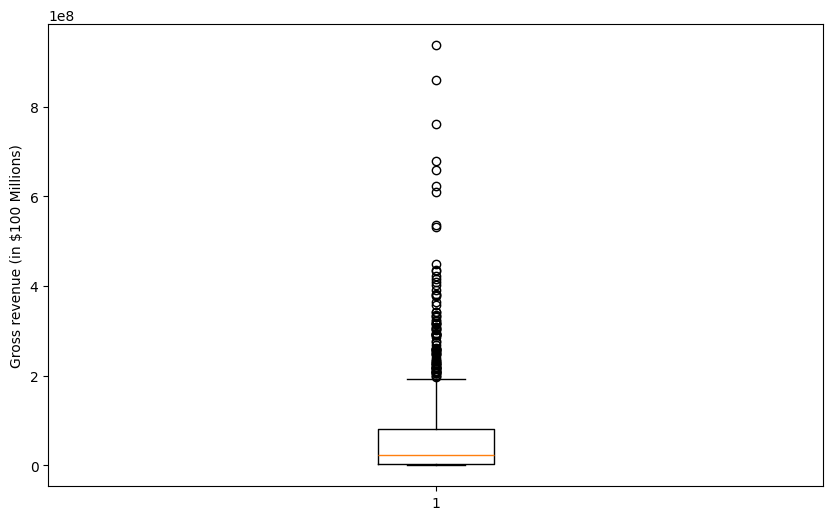

In [106]:
# Visually inspect the outliers and their impact in skewness with a boxplot
plt.figure(figsize=(10,6))
plt.boxplot(df['Gross'].dropna())
plt.ylabel('Gross revenue (in $100 Millions)')
plt.show()

**Observation**: Given the strong right skew and long tail, we opt for a *log transformation* to reduce the skewness of the data, thus preserving the ranking in revenue and the blockbuster signal (which is informative and not noise)

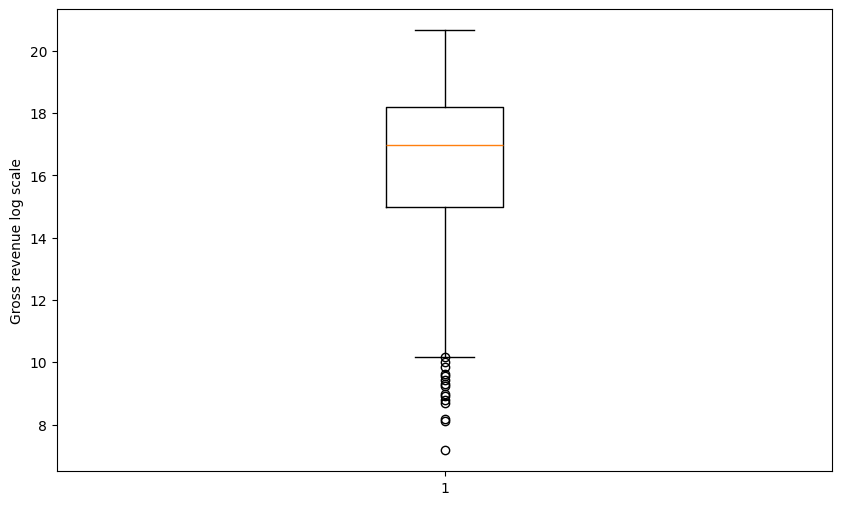

In [107]:
# New log transform column
df["Gross_log"] = np.log1p(df["Gross"])

plt.figure(figsize=(10,6))
plt.boxplot(df['Gross_log'].dropna())
plt.ylabel('Gross revenue log scale')
plt.show()

**Observation**: Note that now:

- Distribution is much more symmetric
- Box is well spread
- Upper tail compressed
- Only a small number of low-end outliers remain (see the next code box below)

In [108]:
# Calculate IQR for 'Gross_log'
Q1 = df['Gross_log'].quantile(0.25).round(2)
Q3 = df['Gross_log'].quantile(0.75).round(2)
IQR = (Q3 - Q1).round(2)
# Calculate upper/lower bounds
# Count outliers

lower_bound = (Q1 - 1.5 * IQR)
upper_bound = (Q3 + 1.5 * IQR)

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

outliers = df[(df['Gross_log'] < lower_bound) | (df['Gross_log'] > upper_bound)]

print(f"Outliers detected: {len(outliers)/len(df) * 100:.1f}% of data")

Q1 (25th percentile): 15.0
Q3 (75th percentile): 18.21
IQR: 3.21
Lower bound: 10.185
Upper bound: 23.025
Outliers detected: 1.6% of data


**Observation**: Note that after the log transformation, the outliers are reduced to a much lower, acceptable percentage -- as desired.

In [109]:
# Check the profile of the first 20 movies with null values in 'Gross'
df[df["Gross"].isna()].head(20)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Gross_log
18,https://m.media-amazon.com/images/M/MV5BNjViNW...,Hamilton,2020,PG-13,160 min,"Biography, Drama, History",8.6,The real life of one of America's foremost fou...,90.00000,Thomas Kail,Lin-Manuel Miranda,Phillipa Soo,Leslie Odom Jr.,Renée Elise Goldsberry,55291,NaN,NaN
20,https://m.media-amazon.com/images/M/MV5BOTc2ZT...,Soorarai Pottru,2020,U,153 min,Drama,8.6,"Nedumaaran Rajangam ""Maara"" sets out to make t...",77.97153,Sudha Kongara,Suriya,Madhavan,Paresh Rawal,Aparna Balamurali,54995,NaN,NaN
30,https://m.media-amazon.com/images/M/MV5BYjBmYT...,Seppuku,1962,U,133 min,"Action, Drama, Mystery",8.6,When a ronin requesting seppuku at a feudal lo...,85.00000,Masaki Kobayashi,Tatsuya Nakadai,Akira Ishihama,Shima Iwashita,Tetsurô Tanba,42004,NaN,NaN
32,https://m.media-amazon.com/images/M/MV5BZjc4ND...,It's a Wonderful Life,1946,PG,130 min,"Drama, Family, Fantasy",8.6,An angel is sent from Heaven to help a despera...,89.00000,Frank Capra,James Stewart,Donna Reed,Lionel Barrymore,Thomas Mitchell,405801,NaN,NaN
46,https://m.media-amazon.com/images/M/MV5BZmY2Nj...,Hotaru no haka,1988,U,89 min,"Animation, Drama, War",8.5,A young boy and his little sister struggle to ...,94.00000,Isao Takahata,Tsutomu Tatsumi,Ayano Shiraishi,Akemi Yamaguchi,Yoshiko Shinohara,235231,NaN,NaN
54,https://m.media-amazon.com/images/M/MV5BNWJhMD...,Ayla: The Daughter of War,2017,U,125 min,"Biography, Drama, History",8.4,"In 1950, amid-st the ravages of the Korean War...",77.97153,Can Ulkay,Erdem Can,Çetin Tekindor,Ismail Hacioglu,Kyung-jin Lee,34112,NaN,NaN
55,https://m.media-amazon.com/images/M/MV5BY2FiMT...,Vikram Vedha,2017,UA,147 min,"Action, Crime, Drama",8.4,"Vikram, a no-nonsense police officer, accompan...",77.97153,Gayatri,Pushkar,Madhavan,Vijay Sethupathi,Shraddha Srinath,28401,NaN,NaN
76,https://m.media-amazon.com/images/M/MV5BYmYzNm...,Anand,1971,U,122 min,"Drama, Musical",8.4,The story of a terminally ill man who wishes t...,77.97153,Hrishikesh Mukherjee,Rajesh Khanna,Amitabh Bachchan,Sumita Sanyal,Ramesh Deo,30273,NaN,NaN
77,https://m.media-amazon.com/images/M/MV5BOTI4NT...,Tengoku to jigoku,1963,U,143 min,"Crime, Drama, Mystery",8.4,An executive of a shoe company becomes a victi...,77.97153,Akira Kurosawa,Toshirô Mifune,Yutaka Sada,Tatsuya Nakadai,Kyôko Kagawa,34357,NaN,NaN
80,https://m.media-amazon.com/images/M/MV5BNjViMm...,Paths of Glory,1957,A,88 min,"Drama, War",8.4,"After refusing to attack an enemy position, a ...",90.00000,Stanley Kubrick,Kirk Douglas,Ralph Meeker,Adolphe Menjou,George Macready,178092,NaN,NaN


**Observation**: Missing Gross values are not random and are concentrated among foreign and older films, suggesting reporting bias rather than measurement error. Because the missingness is informative, values were not globally imputed. Analyses that require Gross use available-case data only.

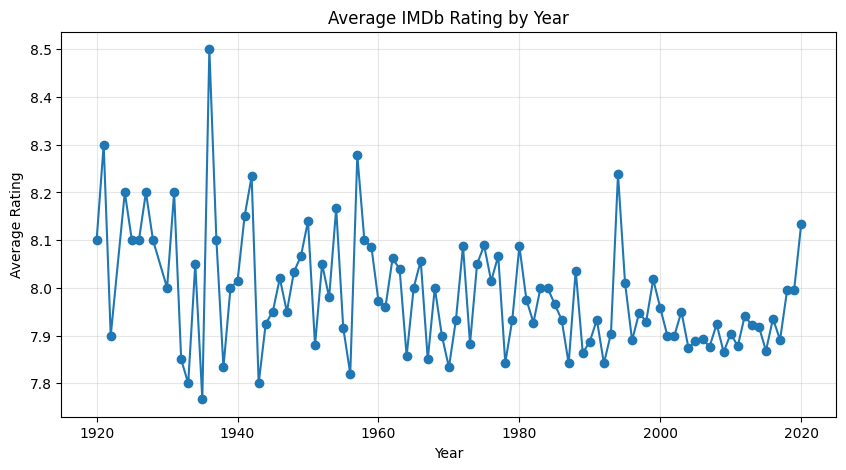

In [110]:
# Turn Released_Year into numeric data to allow chronological ordering
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

# Group IMDb mean ratings by year of release
yearly = (
    df.groupby("Released_Year")["IMDB_Rating"]
      .mean()
      .sort_index()
      .reset_index()  # Turn panda Series into DataFrame using reset_index
)

# Plot the graph of yearly DataFrame
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    yearly["Released_Year"],
    yearly["IMDB_Rating"],
    marker="o",        # optional — helps visibility
    linewidth=1.5
)

ax.set_title("Average IMDb Rating by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Rating")
ax.grid(alpha=0.3)

plt.show()

**Observation**: The average IMDb rating per year remains relatively stable across decades, generally fluctuating between about 7.8 and 8.2. No strong long-term upward or downward trend is visible. This stability is likely influenced by the dataset composition, which includes predominantly highly rated films rather than a random sample of all releases, compressing variation across years.

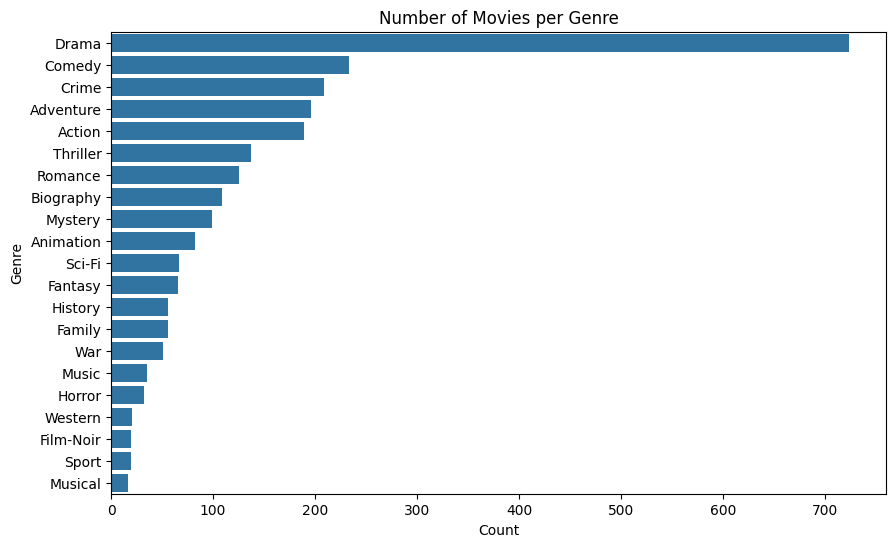

In [111]:
# Create a padas Series with index=genres and values=count per genre
genre_counts = (
    df["Genre"]
      .str.split(",")   # split str into lists (to deal with e.g. 'Action, Drama')
      .explode()    # now one row per movie-genre pair
      .str.strip()  # remove extra spaces
      .value_counts()   # count the occurances for each genre
)

# Create barplot 
plt.figure(figsize=(10,6))

sns.barplot(
    x=genre_counts.values, # this will be a horizontal barplot
    y=genre_counts.index
)

plt.title("Number of Movies per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

**Observation**: The barplot clearly shows that 'Drama' is the most popular movie genre, while the least popular one is 'Musical'. 

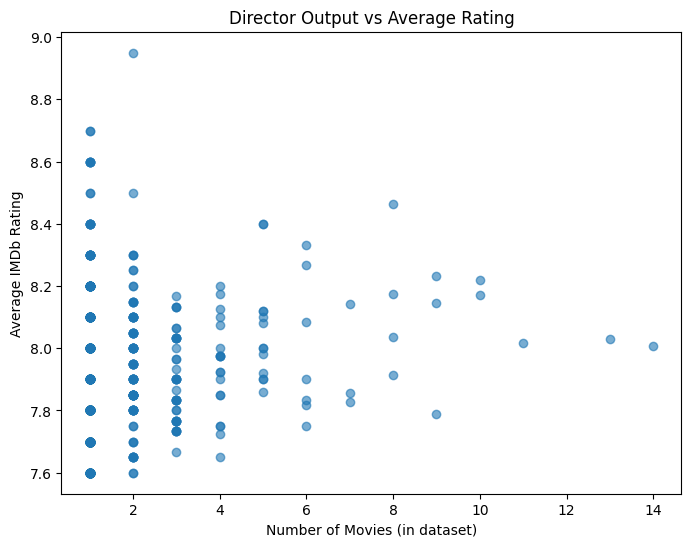

In [112]:
# aggregate average ratings and movie count per director
director_stats = (
    df.groupby("Director")
      .agg(
          avg_rating=("IMDB_Rating", "mean"),
          movie_count=("Series_Title", "count")
      )
      .reset_index()
)

# Create scatter plot
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    director_stats["movie_count"],
    director_stats["avg_rating"],
    alpha=0.6
)

ax.set_xlabel("Number of Movies (in dataset)")
ax.set_ylabel("Average IMDb Rating")
ax.set_title("Director Output vs Average Rating")

plt.show()

**Observation**: Directors are categorical and unordered, so a direct scatter plot of director vs rating is not meaningful. Instead, I aggregated ratings per director and plotted average rating vs number of movies, producing a valid numeric-to-numeric scatter relationship.
Visual inspection doesn't seem to indicate a clear relationship between the two variables.

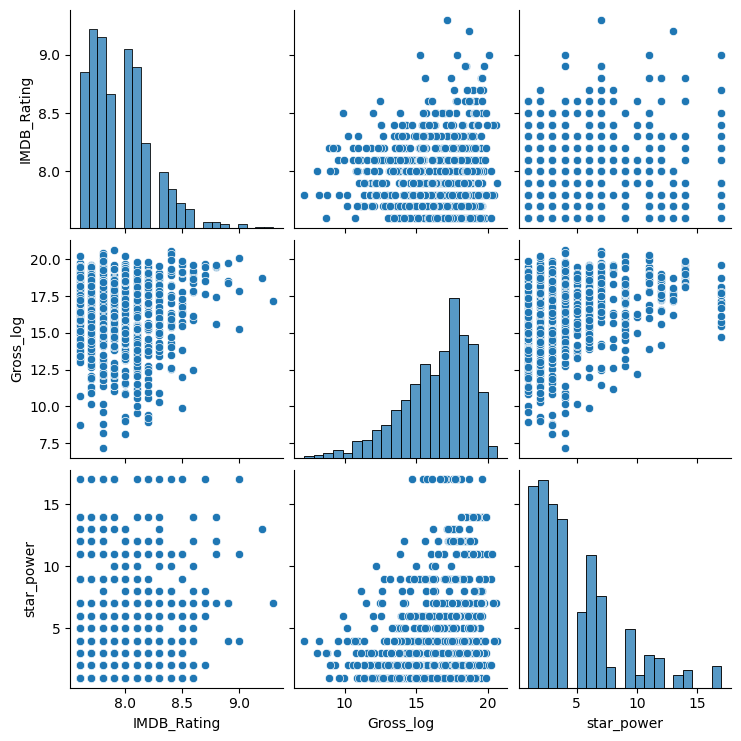

In [113]:
# stack all stars into one column
stars_long = (
    df[["Star1","Star2","Star3","Star4"]]
      .stack()
)

# compute actor frequency
star_freq = stars_long.value_counts()

# define “star power” per movie
def star_power(row):
    return max(
        star_freq.get(row["Star1"], 0),
        star_freq.get(row["Star2"], 0),
        star_freq.get(row["Star3"], 0),
        star_freq.get(row["Star4"], 0),
    )

df["star_power"] = df.apply(star_power, axis=1)

# create pairplot
cols = [
    "IMDB_Rating",
    "Gross_log",
    "star_power"
]

sns.pairplot(df[cols])
plt.show()

**Observation**: The pairplot shows that IMDb ratings are tightly concentrated at the high end of the scale and exhibit slight left skewness, which reflects the dataset’s focus on highly rated films. Log-transformed gross revenue displays a moderate right-skewed distribution, indicating that while most films earn moderate revenue, a smaller number achieve very high box office results even after scaling. The derived star_power metric is strongly right-skewed and discrete, with most films featuring less frequently appearing actors and a small number featuring highly recurrent stars. In the pairwise relationships, there is a weak positive association between star_power and gross revenue, suggesting that films with more prominent stars tend to earn more, while IMDb rating shows little visible relationship with star_power and only a very weak relationship with revenue overall.

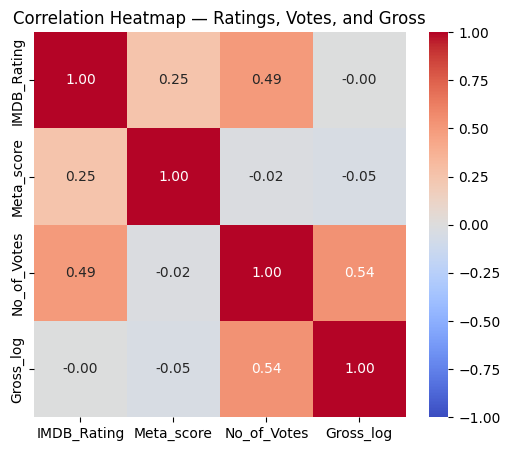

In [114]:
# Create list of columns for heatmap
heat_cols = [
    "IMDB_Rating",
    "Meta_score",
    "No_of_Votes",
    "Gross_log"
]


corr = df[heat_cols].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Heatmap — Ratings, Votes, and Gross")
plt.show()

**Observation**: The correlation heatmap shows that the strongest relationship exists between number of votes and gross revenue (r ≈ 0.54), indicating that more widely viewed films tend to generate higher box office earnings. IMDb rating also shows a moderate positive correlation with number of votes (r ≈ 0.49), suggesting that more highly rated films attract more audience engagement. The relationship between Meta score and IMDb rating is weak (r ≈ 0.25), indicating limited agreement between critic and user evaluations. Gross revenue shows essentially no correlation with IMDb rating, suggesting that commercial success is largely independent of user rating in this dataset.